In [1]:
import numpy as np
import pandas as pd
import csv
import sys
import math
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
from scipy.spatial.distance import cosine, euclidean
import matplotlib.pyplot as plt
import scipy
from matplotlib.pyplot import rcParams
plt.rcParams['figure.facecolor'] = 'w'

In [2]:
# data = pd.read_csv("Doc2Vec_Output/With_1_pair_5_title2vec_node2vec.csv",skiprows=1,header=None)
# data.columns=["id","Author","Title","node_id"]+["Network_dim"+str(i) for i in range(5)]+["Title_index"]+["Title_dim"+str(i) for i in range(5)]+["Time","Read","Max_layer"]
data = pd.read_csv("Titlemodel_Output/Stat_Title_model_topic_vec_features_1000_topics_3.csv",header=0)
data["Read"].astype(int)
red_pocket_title=[u'下雨天宅家里？万元巨款你不准备要了吗！<长沙转发有礼>',
u'【周年店庆邀请函】丨点开有惊喜，转发有红包',
u'名匠心，设计情丨2017名匠杯设计大赛盛大启动',
u'【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动',
u'年度特权日 装修特权价｜名匠2017年度【消费者特权日】盛大启幕',
u'眼要急！手要快！装修特权卡全城抢疯了',
u'开业特权 尊享钜惠 | 名匠装饰集团5家地市新店齐开',
u'国庆装修大动作！如此疯狂钜惠怎能错过？（前3000名转发有红包）',
u'抢定年度特权卡，装修钜惠更疯狂！（转发有红包）',
u'抢定年度特权卡，装修钜惠更疯狂！']

# RP_I=[]
# for index, row in data.iterrows():
#     if row.Title in red_pocket_title: RP_I.append(1)
#     else: RP_I.append(0)
# data["RP_I"]=RP_I
# # data=data[data.RP_I==0]
# data=data[data.Read>1]

In [4]:
author_list=list(set(data.Author))
sim_title=[]
# sim_network=[]
e_title=[]
# e_network=[]
read=[]
read_norm=[]
layer=[]
layer_norm=[]
df_author = []
df_title = []

for author in author_list:
# author=u'刘栋梁'
    data_temp=data[data.Author==author]
    data_temp.sort_values(by=['Time'])
    layers=data_temp.Max_layer.tolist()
    reads=data_temp.Read.tolist()
    max_layer, min_layer=max(layers), min(layers)
    max_read, min_read=max(reads), min(reads)
    # norm_read_temp=[[max_read-min_read]*len(data_temp)]
    # norm_layer_temp=[[max_layer-min_layer]*len(data_temp)]

    count=0
    for index, row in data_temp.iterrows():
        vec_title=np.array([float(row[j]) for j in ["Topic_"+str(i) for i in range(3)]])
        # vec_title=np.array([float(row[j]) for j in ["Title_dim"+str(i) for i in range(5)]])
        # vec_network=np.array([float(row[j]) for j in ["Network_dim"+str(i) for i in range(5)]])
        df_author.append(row.Author)
        df_title.append(row.Title)
        if count==0:
            hist_title=np.array([vec_title])
            # hist_network=np.array([vec_network])
            sim_title.append('N/A')
            e_title.append('N/A')
            # sim_network.append(None)
        else:
            avg_title=np.average(hist_title,axis=0)
            # avg_network=np.average(hist_network,axis=0)
            sim_title.append(1-cosine(vec_title,avg_title))
            # sim_network.append(1-cosine(vec_network,avg_network))
            e_title.append(euclidean(vec_title,avg_title))
            # e_network.append(euclidean(vec_network,avg_network))
            hist_title=np.append(hist_title,vec_title)
            # hist_network=np.append(hist_network,vec_network)
        read.append(math.log(row.Read))
        read_norm.append((math.log(row.Read)-math.log(min_read))/(math.log(max_read+1)-math.log(min_read)))
        layer.append(row.Max_layer)
        layer_norm.append((row.Max_layer-min_layer)/(max_layer+1-min_layer))
        count+=1

# df=pd.DataFrame('sim_title':sim_title,'sim_network':sim_network,'e_title':e_title,'e_network':e_network,'read':read,'read_norm':read_norm,'layer':layer,'layer_norm':layer_norm})

df=pd.DataFrame({'Author':df_author,'Title':df_title,'sim_title':sim_title,'e_title':e_title,'read':read,'read_norm':read_norm,'layer':layer,'layer_norm':layer_norm})
df.to_csv("LDA_His.csv")

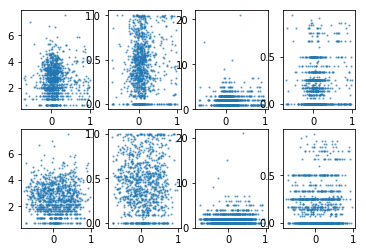

In [77]:
plt.subplot(241)
plt.scatter(df.sim_title[:1000],df.read[:1000],alpha=0.5,s=1.5)
plt.subplot(242)
plt.scatter(df.sim_title[:1000],df.read_norm[:1000],alpha=0.5,s=1.5)
plt.subplot(243)
plt.scatter(df.sim_title[:1000],df.layer[:1000],alpha=0.5,s=1.5)
plt.subplot(244)
plt.scatter(df.sim_title[:1000],df.layer_norm[:1000],alpha=0.5,s=1.5)
plt.subplot(245)
plt.scatter(df.sim_network[:1000],df.read[:1000],alpha=0.5,s=1.5)
plt.subplot(246)
plt.scatter(df.sim_network[:1000],df.read_norm[:1000],alpha=0.5,s=1.5)
plt.subplot(247)
plt.scatter(df.sim_network[:1000],df.layer[:1000],alpha=0.5,s=1.5)
plt.subplot(248)
plt.scatter(df.sim_network[:1000],df.layer_norm[:1000],alpha=0.5,s=1.5)
plt.savefig("with_RP_fittest.png", dpi=600)

In [78]:
print(scipy.stats.pearsonr(df.sim_title,df.read),scipy.stats.pearsonr(df.sim_title,df.read_norm),
     scipy.stats.pearsonr(df.sim_title,df.layer),scipy.stats.pearsonr(df.sim_title,df.layer_norm))
print(scipy.stats.pearsonr(df.sim_network,df.read),scipy.stats.pearsonr(df.sim_network,df.read_norm),
     scipy.stats.pearsonr(df.sim_network,df.layer),scipy.stats.pearsonr(df.sim_network,df.layer_norm))

(0.02166666818591053, 0.026228532473443242) (0.0421706771123286, 1.5063278542122762e-05) (0.04222468855126183, 1.4688480097335795e-05) (0.07330800474033078, 5.073569132466206e-14)
(0.0175250190932303, 0.07220218357568899) (0.03088801665705671, 0.0015284584562939962) (0.04200524752450715, 1.626879420628967e-05) (0.050149873035717905, 2.638759327274192e-07)


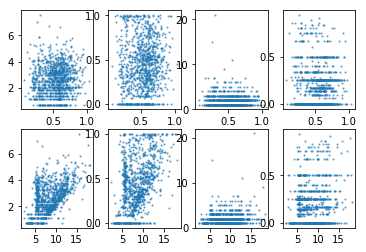

In [93]:
plt.subplot(241)
plt.scatter(df.e_title[:1000],df.read[:1000],alpha=0.5,s=1.5)
plt.subplot(242)
plt.scatter(df.e_title[:1000],df.read_norm[:1000],alpha=0.5,s=1.5)
plt.subplot(243)
plt.scatter(df.e_title[:1000],df.layer[:1000],alpha=0.5,s=1.5)
plt.subplot(244)
plt.scatter(df.e_title[:1000],df.layer_norm[:1000],alpha=0.5,s=1.5)
plt.subplot(245)
plt.scatter(df.e_network[:1000],df.read[:1000],alpha=0.5,s=1.5)
plt.subplot(246)
plt.scatter(df.e_network[:1000],df.read_norm[:1000],alpha=0.5,s=1.5)
plt.subplot(247)
plt.scatter(df.e_network[:1000],df.layer[:1000],alpha=0.5,s=1.5)
plt.subplot(248)
plt.scatter(df.e_network[:1000],df.layer_norm[:1000],alpha=0.5,s=1.5)
plt.savefig("with_RP_euclidean_fittest.png", dpi=600)

In [94]:
print(scipy.stats.pearsonr(df.e_title,df.read),scipy.stats.pearsonr(df.e_title,df.read_norm),
     scipy.stats.pearsonr(df.e_title,df.layer),scipy.stats.pearsonr(df.e_title,df.layer_norm))
print(scipy.stats.pearsonr(df.e_network,df.read),scipy.stats.pearsonr(df.e_network,df.read_norm),
     scipy.stats.pearsonr(df.e_network,df.layer),scipy.stats.pearsonr(df.e_network,df.layer_norm))

(0.025007523781051227, 0.010298151737144167) (0.011858903574036208, 0.2237868734686855) (-0.0804708506415119, 1.3616887341426911e-16) (-0.097492294175557, 1.1887346017066652e-23)
(0.56517512404847, 0.0) (0.42452000683418023, 0.0) (0.14415490099812855, 5.561500690665954e-50) (0.09740570434772582, 1.3013553927501548e-23)


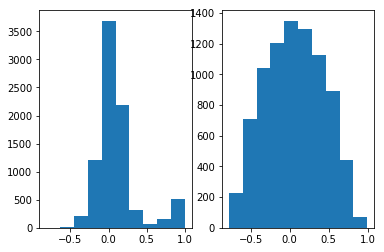

In [68]:
plt.figure()
plt.subplot(121)
plt.hist(df.sim_title)
plt.subplot(122)
plt.hist(df.sim_network)
plt.show()

In [80]:
data_1=data[data.Read==1] # 1262
data_1[data.RP_I==1] # 161/1262 with RP

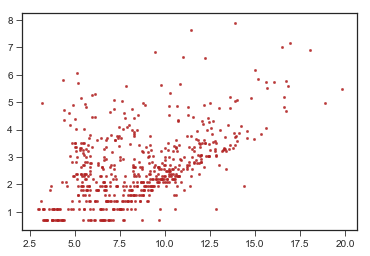

In [31]:
plt.style.use('seaborn-ticks')
plt.scatter(df.e_network[:600],df.read[:600],alpha=0.9,s=5,c='firebrick')
plt.savefig("fit_test_euc_net_log_read.png",format="PNG",dpi=500,facecolor="w")